📊 Dataset Overview
This project analyzes a synthetic dataset of 7,000 entries and 25 variables, designed to explore the relationship between daily screen time, digital habits, and wellbeing indicators (sleep, anxiety, mood, and life satisfaction).

Key Details:

Source: Obtained from Kaggle.

Nature of Data: This is a fully synthetic (simulated) dataset created for educational and analytical purposes. It is not based on real individuals and should not be used for medical or diagnostic conclusions.

Objective: The dataset allows for meaningful Exploratory Data Analysis (EDA) to uncover patterns, such as the correlation between screen usage and mental health, and to test the effectiveness of digital interventions like screen-time limits.

Disclaimer: This dataset uses synthetic proxies for wellbeing and is intended solely for data practice.

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [46]:
df= pd.read_csv('social_media_screentime_mental_health_2026.csv')

In [47]:
df.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [50]:
print(df.columns.tolist())

['participant_id', 'age', 'gender', 'occupation', 'region', 'most_used_platform', 'platforms_used_count', 'daily_screen_hours', 'daily_notifications', 'night_time_use', 'minutes_to_first_check_after_waking', 'primary_purpose', 'avg_sleep_hours', 'anxiety_score_0to27', 'low_mood_score_0to27', 'life_satisfaction_1to10', 'loneliness_1to10', 'self_esteem_1to10', 'fomo_1to10', 'social_comparison_1to10', 'physical_activity_days_per_week', 'uses_screen_time_limits', 'attempted_digital_detox', 'seeks_mental_health_support', 'wellbeing_band']


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   participant_id                       7000 non-null   object 
 1   age                                  7000 non-null   int64  
 2   gender                               6930 non-null   object 
 3   occupation                           7000 non-null   object 
 4   region                               7000 non-null   object 
 5   most_used_platform                   7000 non-null   object 
 6   platforms_used_count                 7000 non-null   int64  
 7   daily_screen_hours                   7000 non-null   float64
 8   daily_notifications                  7000 non-null   int64  
 9   night_time_use                       7000 non-null   object 
 10  minutes_to_first_check_after_waking  7000 non-null   int64  
 11  primary_purpose               

In [49]:
df.isnull().sum()

participant_id                           0
age                                      0
gender                                  70
occupation                               0
region                                   0
most_used_platform                       0
platforms_used_count                     0
daily_screen_hours                       0
daily_notifications                      0
night_time_use                           0
minutes_to_first_check_after_waking      0
primary_purpose                          0
avg_sleep_hours                        105
anxiety_score_0to27                      0
low_mood_score_0to27                     0
life_satisfaction_1to10                  0
loneliness_1to10                         0
self_esteem_1to10                        0
fomo_1to10                               0
social_comparison_1to10                  0
physical_activity_days_per_week          0
uses_screen_time_limits                  0
attempted_digital_detox                  0
seeks_menta

In [12]:
df.dropna(inplace=True) #Clean the empty data, the sample was (7000x25) after we clean it became (6825x25)

The initial dataset comprised 7,000 entries across 25 variables. To ensure the integrity and reliability of our analysis, we performed a data cleaning process to address missing values and inconsistencies. As a result, 175 incomplete entries were removed, leaving a refined sample size of 6,825 entries. This cleaned dataset serves as the foundation for the subsequent analytical phases.

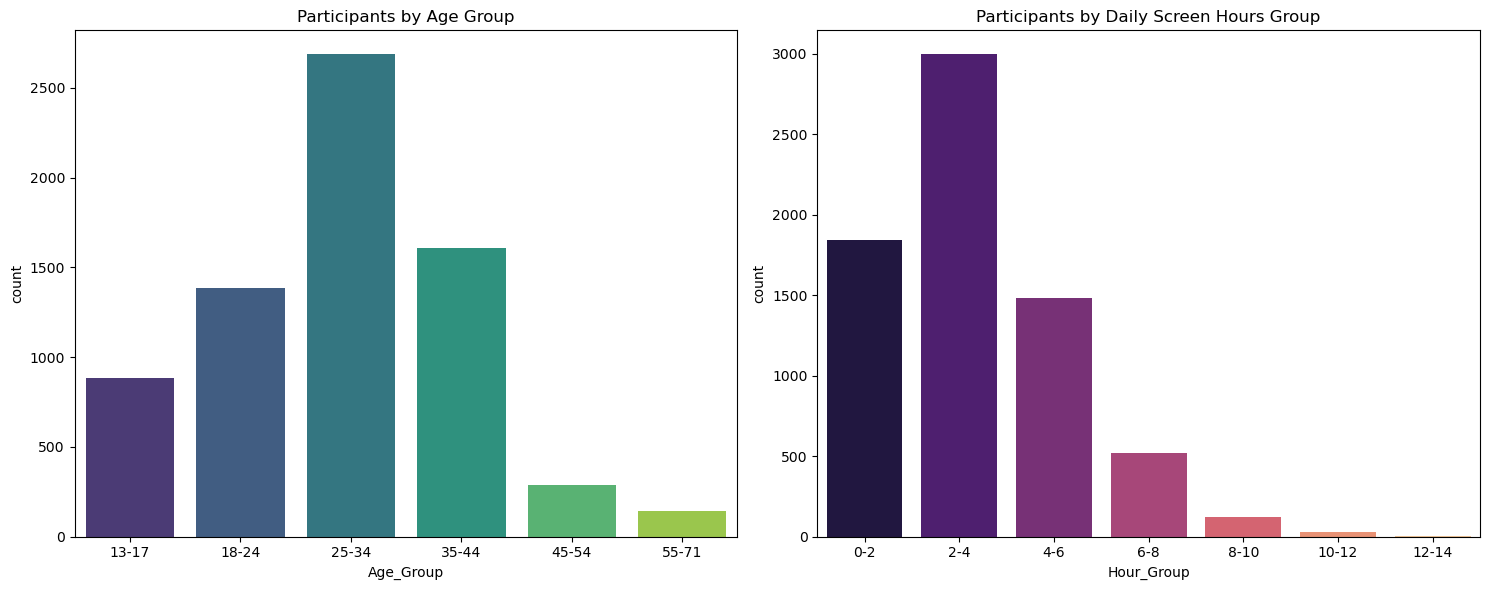

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
bins = [13, 18, 25, 35, 45, 50, 72] 
labels = ['13-17', '18-24', '25-34', '35-44', '45-54', '55-71']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
hour_bins = range(0, 16, 2)
hour_labels = [f'{i}-{i+2}' for i in range(0, 14, 2)]
df['Hour_Group'] = pd.cut(df['daily_screen_hours'], bins=hour_bins, labels=hour_labels, right=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=df, x='Age_Group', ax=axes[0], palette='viridis', hue='Age_Group', legend=False)
axes[0].set_title('Participants by Age Group')
sns.countplot(data=df, x='Hour_Group', ax=axes[1], palette='magma', hue='Hour_Group', legend=False)
axes[1].set_title('Participants by Daily Screen Hours Group')
plt.tight_layout()
plt.savefig('age_group,Hour_group.png', dpi=300)
plt.show()

📊 Demographic and Usage Distribution Analysis
"To better understand the sample structure, we categorized participants into specific demographic and behavioral cohorts.

Key Observations:

Age Distribution: The analysis reveals that the majority of participants fall within the 25–34 and 35–44 age brackets, suggesting a sample primarily composed of young adults and working-age professionals.

Screen Time Patterns: Regarding daily usage, the most frequent screen time duration is 2–4 hours, followed closely by 0–2 hours. Notably, the number of participants significantly declines as screen time exceeds 6 hours, indicating that the bulk of our sample maintains moderate digital habits."

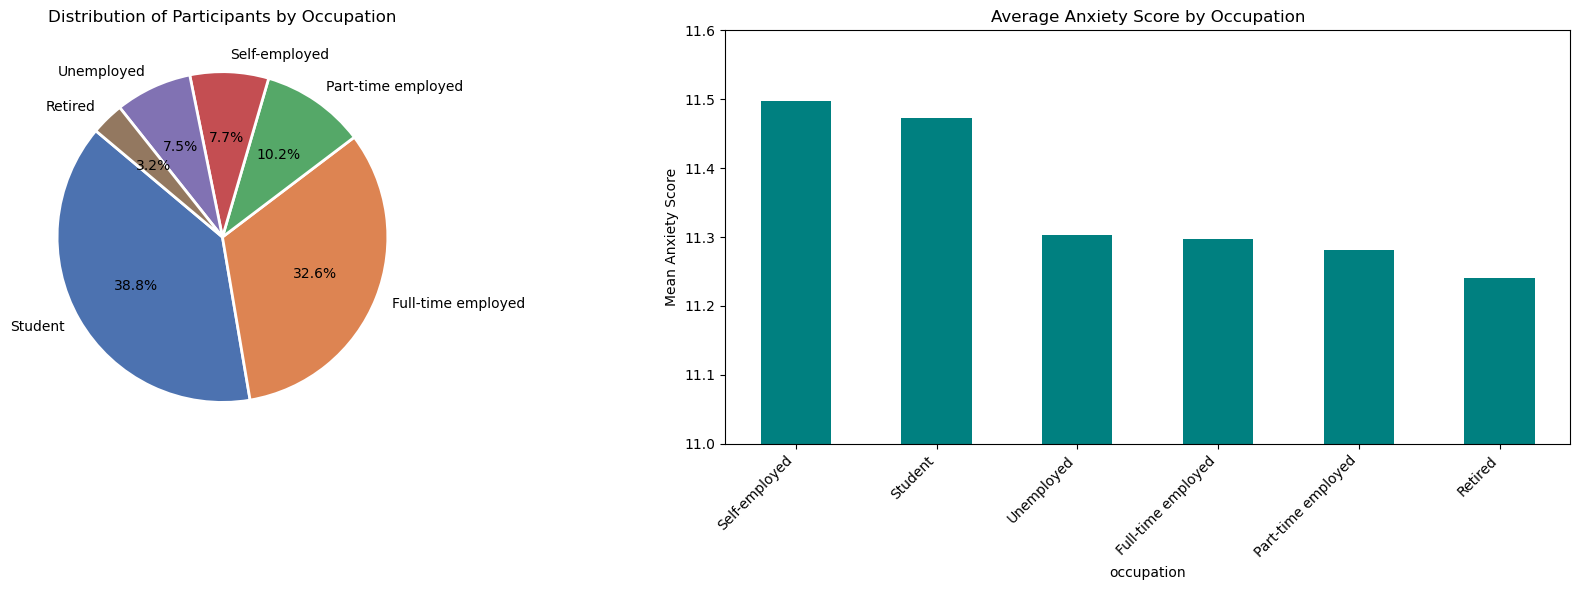

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
occupation_counts = df['occupation'].value_counts()
colors = sns.color_palette('deep', len(occupation_counts))
axes[0].pie(occupation_counts, labels=occupation_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribution of Participants by Occupation')
occupation_anxiety = df.groupby('occupation')['anxiety_score_0to27'].mean().sort_values(ascending=False)
occupation_anxiety.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Average Anxiety Score by Occupation')
axes[1].set_ylabel('Mean Anxiety Score')
axes[1].set_ylim(11, 11.6)
axes[1].set_xticklabels(occupation_anxiety.index, rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Occupation_anxiety.png', dpi=300)
plt.show()

Occupation Profile and Anxiety Levels
The following visualization contrasts the distribution of participants across professional sectors with their corresponding average anxiety scores.

Key Insights:

Sample Composition: The sample is predominantly composed of students (38.6%) and full-time employees (32.7%), together representing the majority of the population.

Anxiety Convergence: Despite the occupational diversity, anxiety scores demonstrate a high degree of stability, hovering within a narrow range (11.2 – 11.5).

Analytical Conclusion: The data indicates that professional status is not a primary driver of anxiety levels in this simulated population. This finding suggests that the factors influencing digital anxiety may be more rooted in behavioral habits—such as screen time duration and platform engagement—rather than the individual's specific job or academic role. This motivates our next phase: exploring the direct correlation between screen usage and mental wellbeing.

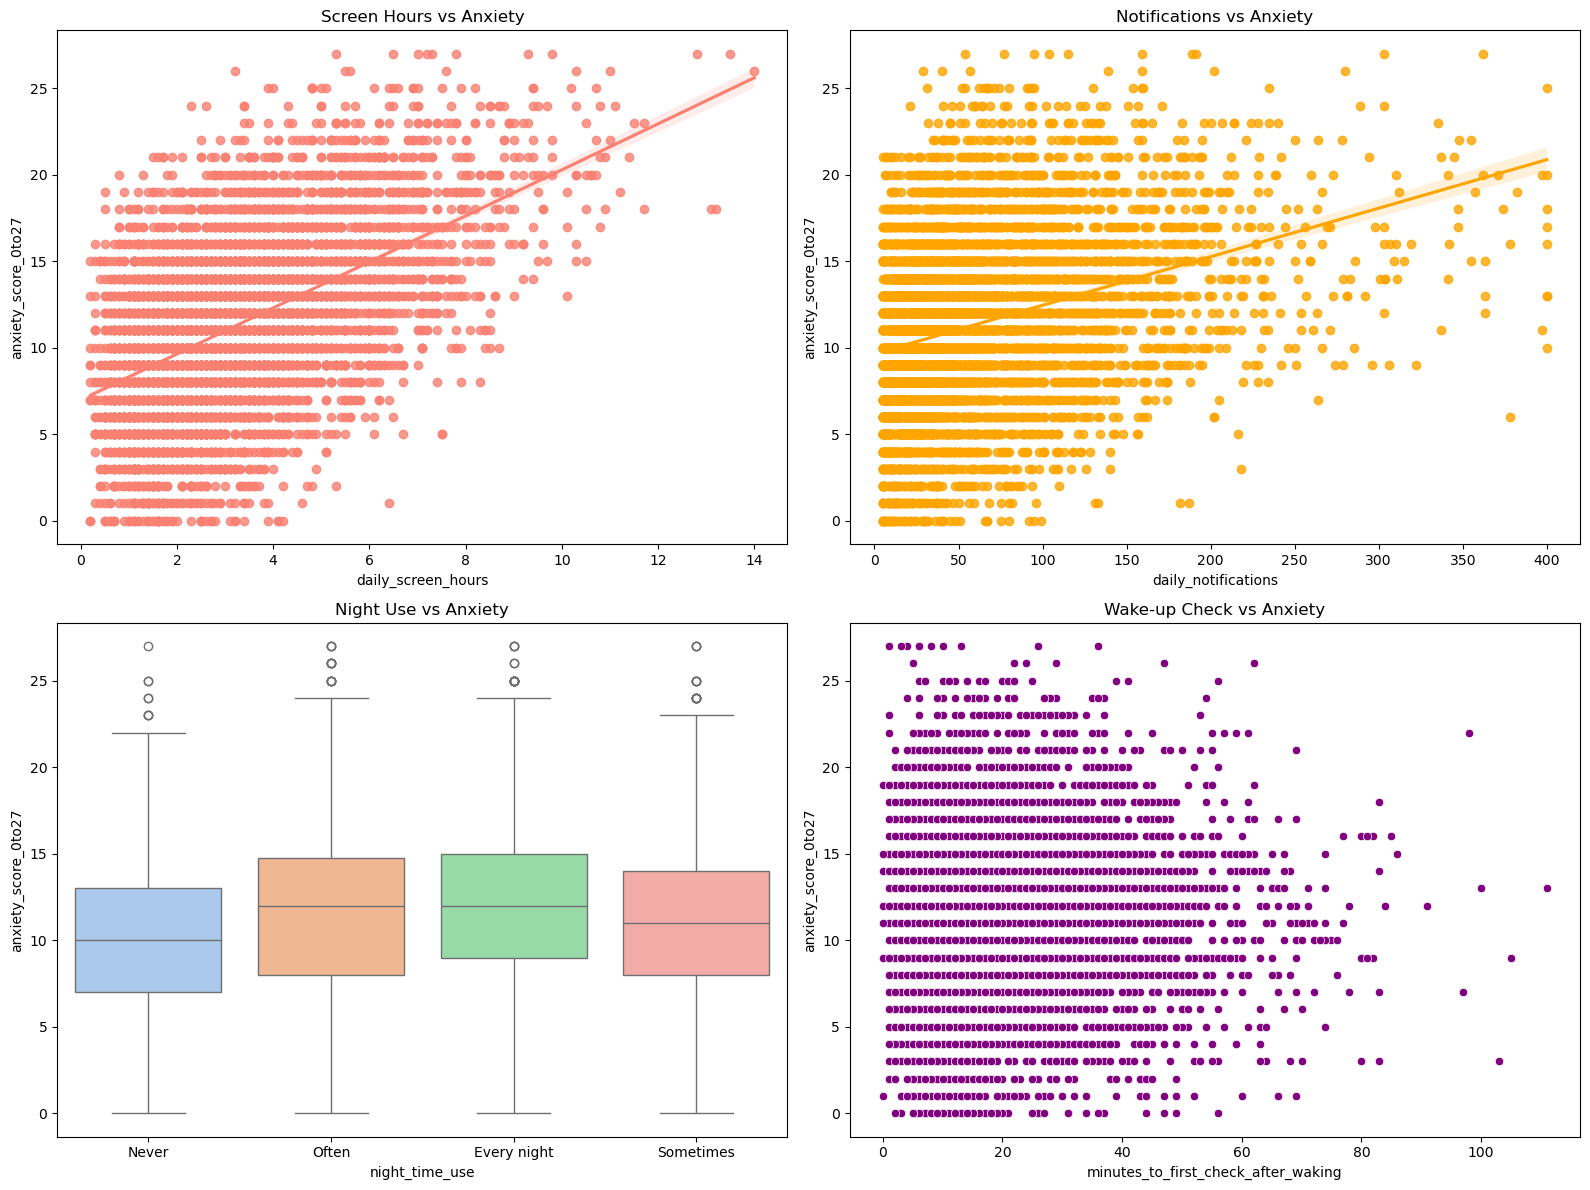

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(data=df, x='daily_screen_hours', y='anxiety_score_0to27', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Screen Hours vs Anxiety')

sns.regplot(data=df, x='daily_notifications', y='anxiety_score_0to27', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Notifications vs Anxiety')

sns.boxplot(data=df, x='night_time_use', y='anxiety_score_0to27', ax=axes[1, 0], palette='pastel', hue='night_time_use', legend=False)
axes[1, 0].set_title('Night Use vs Anxiety')

sns.scatterplot(data=df, x='minutes_to_first_check_after_waking', y='anxiety_score_0to27', ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Wake-up Check vs Anxiety')

plt.tight_layout()
plt.savefig('night_and_morning_habits.png', dpi=300)
plt.show()

📈 Behavioral Drivers of Anxiety
The following visualizations analyze the correlation between digital behaviors and anxiety scores. The findings highlight distinct patterns that impact mental wellbeing:

Screen Time & Notifications: Both 'Daily Screen Hours' and 'Daily Notifications' exhibit a positive linear correlation with anxiety levels. As digital engagement increases, anxiety scores trend upward, suggesting that high-volume digital consumption is a significant stressor.

Night-time Usage: The box plots reveal that individuals who use devices 'Every night' or 'Often' tend to have a slightly higher median anxiety score compared to those who 'Never' use them at night, indicating that late-night digital habits may disrupt essential recovery periods.

Morning Habits: The scatter plot for 'Wake-up Check' shows a downward dispersion, where longer delays in checking the phone after waking correlate with lower anxiety scores. This suggests that creating a 'digital-free' buffer immediately after waking may act as a protective factor against daily anxiety.

Conclusion: These patterns strongly suggest that it is not just the fact of using technology, but the intensity and timing of that usage that influences psychological wellbeing.

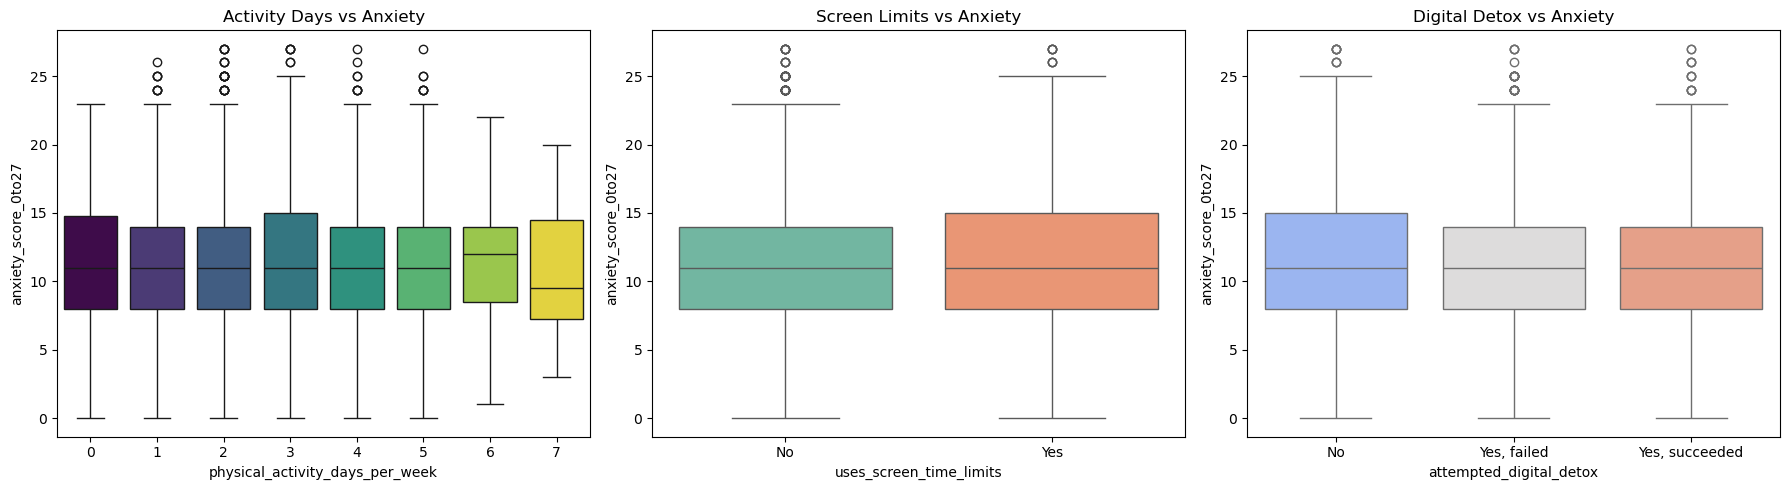

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x='physical_activity_days_per_week', y='anxiety_score_0to27', ax=axes[0], palette='viridis', hue='physical_activity_days_per_week', legend=False)
axes[0].set_title('Activity Days vs Anxiety')
sns.boxplot(data=df, x='uses_screen_time_limits', y='anxiety_score_0to27', ax=axes[1], palette='Set2', hue='uses_screen_time_limits', legend=False)
axes[1].set_title('Screen Limits vs Anxiety')
sns.boxplot(data=df, x='attempted_digital_detox', y='anxiety_score_0to27', ax=axes[2], palette='coolwarm', hue='attempted_digital_detox', legend=False)
axes[2].set_title('Digital Detox vs Anxiety')

plt.tight_layout()
plt.savefig('lifestyle_interventions.png', dpi=300)
plt.show()

Mitigating Factors: Habits and Interventions
In this section, we examine whether behavioral interventions and lifestyle choices correlate with lower anxiety levels.

Key Observations:

Physical Activity: The box plots suggest a slight downward trend in median anxiety scores as physical activity days per week increase, supporting the hypothesis that regular exercise acts as a buffer against digital-induced stress.

Screen Time Limits: Interestingly, the results show minimal difference in anxiety scores between those who use screen limits and those who do not. This indicates that the existence of a rule may not be as critical as the actual usage behavior.

Digital Detox: Similarly, comparing those who attempted a digital detox versus those who did not reveals no significant decrease in anxiety scores for the 'detox' group. This suggests that 'quick-fix' interventions might be less effective than consistent, day-to-day digital hygiene.

Synthesis: These findings highlight a critical takeaway: Consistency over interventions. Relying on binary measures (like 'did I do a detox?') appears less effective for mental wellbeing than maintaining a sustainable, balanced digital lifestyle throughout the week.

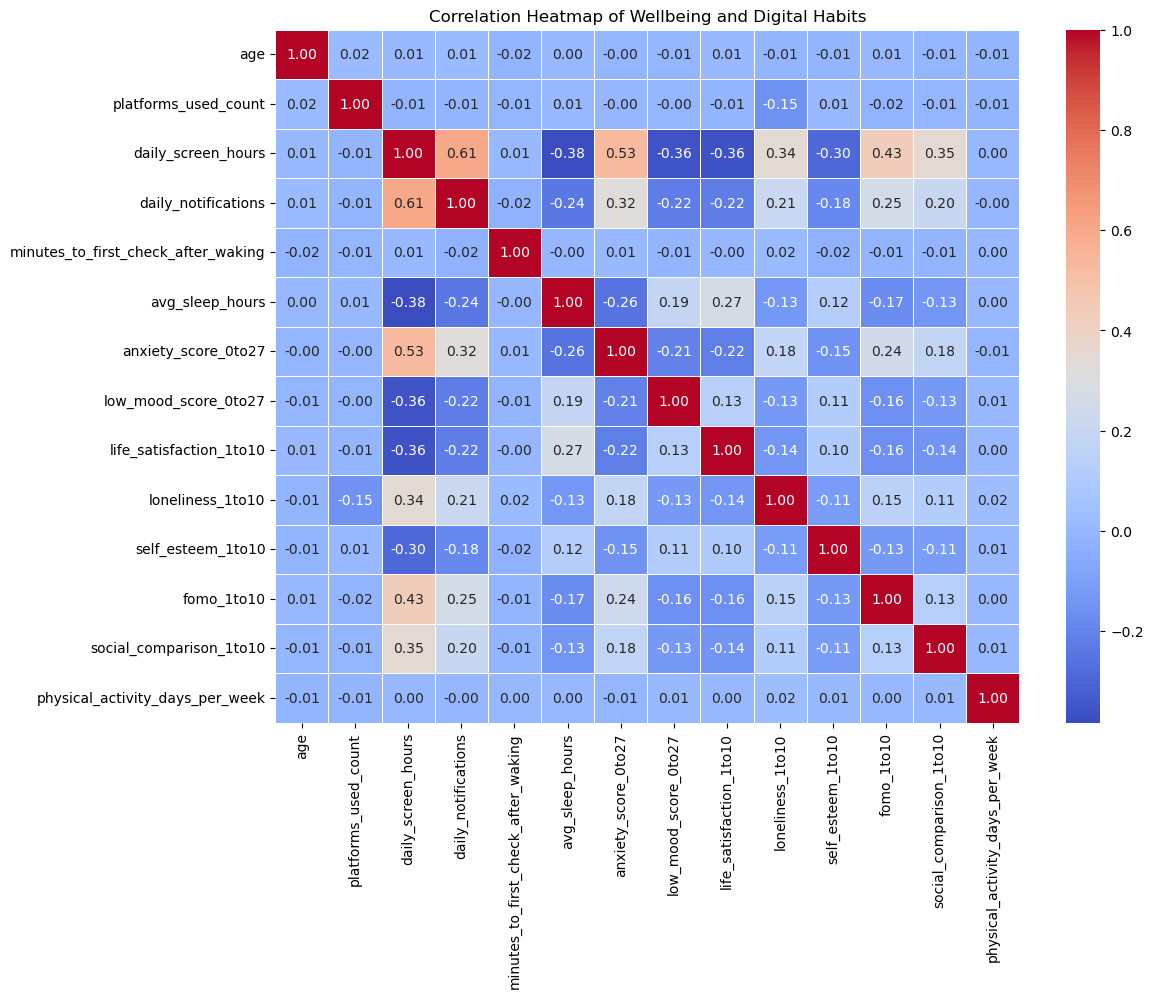

In [57]:
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Wellbeing and Digital Habits')
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

Statistical Correlation Matrix
The correlation heatmap provides a statistical summary of the relationships between digital habits and wellbeing indicators.

Key Observations:

Anxiety Drivers: There is a clear positive correlation (indicated in orange/red) between anxiety_score and both daily_screen_hours (0.53) and daily_notifications (0.32), corroborating our visual analysis.

Wellbeing Inversion: Interestingly, life_satisfaction and avg_sleep_hours show a negative correlation with anxiety_score, highlighting the inverse relationship between quality of life and anxiety.

Validation of Factors: The heatmap confirms that fomo (Fear Of Missing Out) and social_comparison are also positively linked to anxiety, acting as psychological mediators that link excessive screen time to increased anxiety scores.

Final Conclusion: This analysis suggests that digital wellbeing is a multifaceted issue. While screen time is a primary stressor, it operates within a network of psychological factors (FOMO, sleep quality, and social comparison) that collectively influence an individual's mental health. This underscores the need for a holistic approach to digital wellness.